In [52]:
# Imports
import path_simulator
import payoffs
from estimators import finite_difference
from estimators import pathwise
from estimators import likelihood_ratio

import numpy as np
import pandas as pd
import time

from scipy.stats import norm
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import LogLocator, FormatStrFormatter

Similarly to European call options, Asian call options have continuous payoff functions. Thus, most of the analysis conducted on the Monte Carlo estimation of their Delta is similar. However, Asian call options introduce an additional parameter with a possibly relevant effect on the MSE of approximations, namely the number of monitoring dates used for the computation of the payoff at maturity.

Firstly, we establish the main parameters of the Asian call used in this Notebook.

In [53]:
# Parameters of the Asian call option
s = 100
K = 100
T = 1
r = 0.05
vol = 0.25
steps = 4 # quarterly monitoring
reps = 10000

Throughout this notebook, $M$ denotes the number of simulated time intervals. Since the path simulator also stores the initial value $S_0$, each path contains $M+1$ values,

$$
S_0,S_{T/M},S_{2T/M},\ldots,S_T,
$$

and the arithmetic average is computed over all $M+1$ values. Thus, quarterly monitoring corresponds to $M=4$.

There is no closed-form formula for the Delta of an Asian call option under Black-Scholes assumptions. Given that the best estimator for European calls was found to be the Pathwise Differentiation estimator and that the Asian call payoff is continuous too, we use a very-high-rep pathwise estimation for the main Asian call investigated.

In [54]:
# Compute 'real' Delta
real_delta = pathwise.mc_asian_call_delta_pw_estimate(s,K,T,r,vol,steps,10_000_000)

## Finite Differences

We begin by approximating the Delta of the Asian call with the above parameter values using the Forward Difference and Central Difference methods, varying the value of $reps$ and the step size $h$.

In [55]:
# Values to investigate
reps_values = np.logspace(3, 6, 7, dtype=int)
h_values = np.logspace(-2, 2, 9)

In [56]:
trials = 5

# Rows correspond to reps, columns correspond to h
fd_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd = finite_difference.mc_asian_call_delta_fd_estimate(s,K,T,r,vol,steps,reps_i,h_j)
            trial_errors[trial] = (delta_fd - real_delta)**2
        fd_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
fd_error_table = pd.DataFrame(fd_mse, index=reps_values, columns=h_values)

fd_error_table.index.name = "reps"
fd_error_table.columns.name = "h"

display(fd_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,1769.871313,229.967513,5.110480,2.332552,0.047919,0.004818,0.028672,0.071485,0.127016
3162,619.285935,96.195719,4.585483,1.904115,0.054741,0.016390,0.011677,0.079123,0.127284
10000,27.819306,22.855033,2.624519,0.369201,0.030039,0.000974,0.015729,0.073739,0.128463
31622,63.758502,6.148856,0.753552,0.048251,0.002912,0.001806,0.015804,0.073615,0.128510
100000,27.972920,2.584675,0.043484,0.035239,0.003543,0.002208,0.015105,0.072282,0.127966
316227,10.222635,0.304712,0.054399,0.004385,0.001969,0.001234,0.015337,0.073109,0.128646
1000000,1.102813,0.348386,0.030291,0.002558,0.000771,0.001486,0.015319,0.073109,0.128424


For the Forward Difference method, increasing the number of $reps$ reduces the MSE as expected, and the optimal value of $h$ appears to become smaller as the number of reps $N$ increases. This behaviour is qualitatively identical to the one observed for European calls.

Next, we repeat this table for the Central Difference method.

In [57]:
trials = 5

# Rows correspond to reps, columns correspond to h
cd_mse = np.empty((len(reps_values), len(h_values)))

# Populate the table
for i, reps_i in enumerate(reps_values):
    for j, h_j in enumerate(h_values):
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_asian_call_delta_cd_estimate(s,K,T,r,vol,steps,reps_i,h_j)
            trial_errors[trial] = (delta_cd - real_delta)**2
        cd_mse[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
cd_error_table = pd.DataFrame(cd_mse, index=reps_values, columns=h_values)

cd_error_table.index.name = "reps"
cd_error_table.columns.name = "h"

display(cd_error_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
reps,,,,,,,,,
1000,625.785292,68.817301,6.569715,0.395702,0.046859,0.005101,0.001430,0.001627,0.005267
3162,182.514481,2.588517,0.955375,0.173438,0.005805,0.000255,0.000296,0.002289,0.005543
10000,17.837406,0.706324,0.256917,0.094309,0.006264,0.000245,0.000096,0.002556,0.005655
31622,5.609638,3.057172,0.382718,0.007363,0.001115,0.000113,0.000118,0.002489,0.005704
100000,3.571568,0.246075,0.028465,0.001888,0.000224,0.000030,0.000094,0.002288,0.005657
316227,0.704064,0.152503,0.010834,0.001857,0.000317,0.000027,0.000083,0.002420,0.005697
1000000,0.330542,0.093044,0.001858,0.000265,0.000052,0.000006,0.000089,0.002412,0.005701


We observe an identical behaviour to the above, although the MSE values are smaller across the $(N, h)$ pairs for the Central difference method. The graphs below serve as a visual reference.

In [58]:
shared_vmin = min(fd_mse[fd_mse > 0].min(),cd_mse[cd_mse > 0].min())

shared_vmax = max(fd_mse.max(),cd_mse.max())

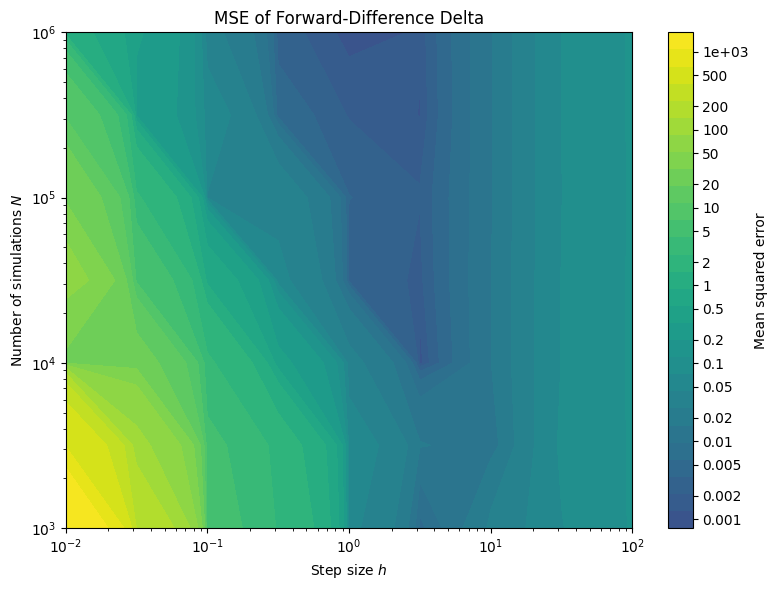

In [59]:
H, N = np.meshgrid(h_values, reps_values)

# Bounds of the plot
vmin = fd_mse[fd_mse > 0].min()
vmax = fd_mse.max()

plt.figure(figsize=(8, 6))

levels = np.geomspace(vmin, vmax, 30)
contour = plt.contourf(H,N,fd_mse,levels=levels,norm=LogNorm(vmin=shared_vmin, vmax=shared_vmax))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size $h$")
plt.ylabel("Number of simulations $N$")
plt.title("MSE of Forward-Difference Delta")

cbar = plt.colorbar(contour)
cbar.locator = LogLocator(base=10,subs=(1, 2, 5),numticks=20)
cbar.formatter = FormatStrFormatter("%.3g")
cbar.update_ticks()
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

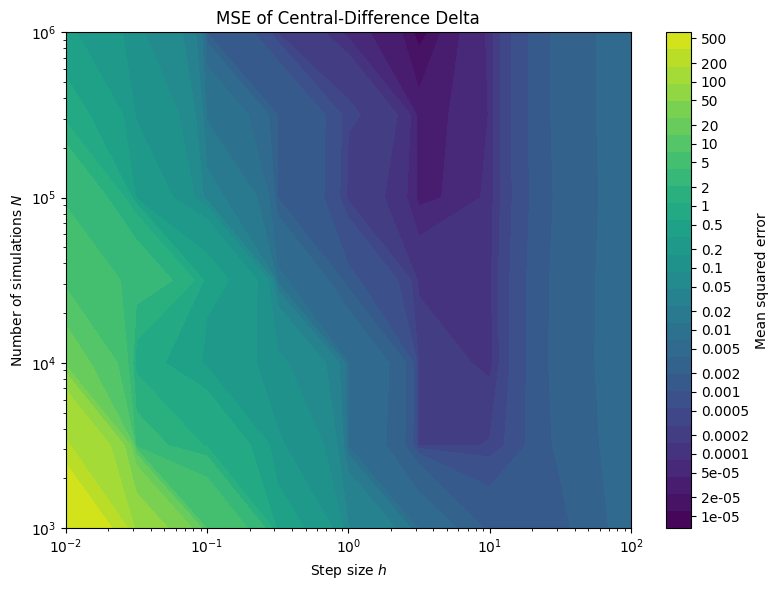

In [60]:
# Bounds for the plot
H, N = np.meshgrid(h_values, reps_values)

vmin = cd_mse[cd_mse > 0].min()
vmax = cd_mse.max()

plt.figure(figsize=(8, 6))

levels = np.geomspace(vmin, vmax, 30)
contour = plt.contourf(H,N,cd_mse,levels=levels,norm=LogNorm(vmin=shared_vmin, vmax=shared_vmax))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size $h$")
plt.ylabel("Number of simulations $N$")
plt.title("MSE of Central-Difference Delta")

cbar = plt.colorbar(contour)
cbar.locator = LogLocator(base=10,subs=(1, 2, 5),numticks=20)
cbar.formatter = FormatStrFormatter("%.3g")
cbar.update_ticks()
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

Next, we investigate the effect of increasing the number of time intervals $M$, and hence the number of averaged path values $M+1$, on the MSE of the Delta approximation. We repeat the process above, this time replacing the variable $N$ with $M$. We use the Central Difference method for greater accuracy and fix $N=1000$. Since the true Delta cannot be computed analytically for each value of $M$, we use a high-rep Pathwise approximation as an equivalent.

In [61]:
reps = 1000
steps_values = np.logspace(0, 3, 7, dtype=int)

In [62]:
trials = 5

# Rows correspond to steps, columns correspond to h
cd_mse_2 = np.empty((len(steps_values), len(h_values)))

# Populate the table
for i, steps_i in enumerate(steps_values):
    for j, h_j in enumerate(h_values):
        real_delta = pathwise.mc_asian_call_delta_pw_estimate(s,K,T,r,vol,steps,100_000)
        trial_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_asian_call_delta_cd_estimate(s,K,T,r,vol,steps_i,reps,h_j)
            trial_errors[trial] = (delta_cd - real_delta)**2
        cd_mse_2[i, j] = np.mean(trial_errors)

# Convert the results into a labelled table
cd_error_table_2 = pd.DataFrame(cd_mse_2, index=steps_values, columns=h_values)

cd_error_table_2.index.name = "steps"
cd_error_table_2.columns.name = "h"

display(cd_error_table_2)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
steps,,,,,,,,,
1,167.740815,41.888069,2.099125,0.183057,0.079825,0.007452,0.000803,0.002751,0.005539
3,388.866646,45.346049,5.614396,1.078441,0.027453,0.001735,0.000463,0.002275,0.005924
10,239.042268,38.235328,5.523433,0.543762,0.050190,0.003970,0.001477,0.002528,0.005881
31,319.962337,26.181214,5.844851,0.800516,0.042684,0.002919,0.000994,0.002994,0.005395
100,743.074157,25.353865,5.189329,0.401766,0.054651,0.004424,0.000865,0.002598,0.005343
316,252.967272,17.039940,1.518857,0.868581,0.010875,0.002289,0.000590,0.002105,0.005522
1000,643.919980,46.235850,2.474138,0.151874,0.024033,0.002768,0.000144,0.001760,0.005825


In general, there does not seem to be a clear relationship between the number of steps and the MSE of the estimations. Only $h$ appears to have a clear impact.

Next, for previous the $N$ - $h$ table, since we are expecting the same MSE surface to be fitted (up to multiplicative constants) for Europeans and Asians, we repeat the same process as in the European call case to find an optimal-$h$ function. We begin with Forward differences.

In [63]:
# Grid of values
reps_values_fit = np.unique(np.logspace(3, 5, 8, dtype=int))
h_values_fit = np.logspace(-1, 1, 12)

trials = 10

# Empirical MSE values
fd_mse_fit = np.empty((len(reps_values_fit), len(h_values_fit)))

for i, reps_i in enumerate(reps_values_fit):
    for j, h_j in enumerate(h_values_fit):
        squared_errors = np.empty(trials)
        for trial in range(trials):
            delta_fd = finite_difference.mc_asian_call_delta_fd_estimate(s,K,T,r,vol,steps,reps_i,h_j)
            squared_errors[trial] = (delta_fd - real_delta)**2
        fd_mse_fit[i, j] = np.mean(squared_errors)

# Prepare data for fitting
H, N = np.meshgrid(h_values_fit,reps_values_fit)

x_data = np.vstack([N.ravel(), H.ravel()])
y_data = fd_mse_fit.ravel()

# MSE(N,h) ≈ A h^2 + B / (N h^2)
def fd_mse_model(x, A, B):
    N, h = x
    return A * h**2 + B / (N * h**2)

# Estimate A and B
parameters, covariance = curve_fit(fd_mse_model,x_data,y_data,p0=(1e-4, 100),bounds=(0, np.inf))
A_hat_fd, B_hat_fd = parameters

# Print results
print(f"Estimated A = {A_hat_fd:.6e}")
print(f"Estimated B = {B_hat_fd:.6e}")

Estimated A = 1.582795e-04
Estimated B = 1.958359e+02


In [64]:
# Optimal h as a function of N (according to theory)
def h_opt_fd(N):
    return (B_hat_fd/(N*A_hat_fd))**(1/4)

We use the function to compute the approximate optimal step sizes for the values of $N$ tested in the tables.

In [65]:
# Print optimal values
print(f"Optimal step size for N = 1,000 : {h_opt_fd(1_000)}")
print(f"Optimal step size for N = 10,000 : {h_opt_fd(10_000)}")
print(f"Optimal step size for N = 100,000 : {h_opt_fd(100_000)}")
print(f"Optimal step size for N = 1,000,000 : {h_opt_fd(1_000_000)}")

Optimal step size for N = 1,000 : 5.93084963217722
Optimal step size for N = 10,000 : 3.3351618416632327
Optimal step size for N = 100,000 : 1.8754993297651874
Optimal step size for N = 1,000,000 : 1.054670778493767


These results broadly agree with the results from the 'MSE of Forward-Difference Delta' plot. We repeat the process for Central differences.

In [66]:
# Grid of values
reps_values_fit = np.unique(np.logspace(3, 5, 8, dtype=int))
h_values_fit = np.logspace(-1, 1, 12)

trials = 10

# Empirical MSE values
cd_mse_fit = np.empty((len(reps_values_fit), len(h_values_fit)))

for i, reps_i in enumerate(reps_values_fit):
    for j, h_j in enumerate(h_values_fit):
        squared_errors = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_asian_call_delta_cd_estimate(s,K,T,r,vol,steps,reps_i,h_j)
            squared_errors[trial] = (delta_cd - real_delta)**2
        cd_mse_fit[i, j] = np.mean(squared_errors)

# Prepare data for fitting
H, N = np.meshgrid(h_values_fit,reps_values_fit)

x_data = np.vstack([N.ravel(), H.ravel()])
y_data = cd_mse_fit.ravel()

# MSE(N,h) ≈ A h^4 + B / (N h^2)
def cd_mse_model(x, A, B):
    N, h = x
    return A * h**4 + B / (N * h**2)

# Estimate A and B
parameters, covariance = curve_fit(cd_mse_model,x_data,y_data,p0=(1e-4, 100),bounds=(0, np.inf))
A_hat_cd, B_hat_cd = parameters

# Print results
print(f"Estimated A = {A_hat_cd:.6e}")
print(f"Estimated B = {B_hat_cd:.6e}")

Estimated A = 3.066373e-08
Estimated B = 6.123959e+01


In [67]:
# Optimal h as a function of N (according to theory)
def h_opt_cd(N):
    return (B_hat_cd/(2*N*A_hat_cd))**(1/6)

In [68]:
# Print optimal values
print(f"Optimal step size for N = 1,000 : {h_opt_cd(1_000)}")
print(f"Optimal step size for N = 10,000 : {h_opt_cd(10_000)}")
print(f"Optimal step size for N = 100,000 : {h_opt_cd(100_000)}")
print(f"Optimal step size for N = 1,000,000 : {h_opt_cd(1_000_000)}")

Optimal step size for N = 1,000 : 9.99761082830549
Optimal step size for N = 10,000 : 6.811292966852526
Optimal step size for N = 100,000 : 4.6404798783468975
Optimal step size for N = 1,000,000 : 3.161522137740794


Again, the optimal step size results agree with the findings in the corresponding plot. Next, we implement Common Random Numbers to investigate their effectiveness in reducing the MSE. In particular, since it is already known that CRN will reduce the MSE, we focus on the ratio $\frac{\text{MSE}_{\text{CRN}}}{\text{MSE}_{\text{independent}}}$ as a function of the step size $h$ and the number of monitoring dates $M$. We again use the Central Difference method for greater accuracy.

In [69]:
reps = 1000
steps_values = np.logspace(0, 3, 7, dtype=int)

In [70]:
trials = 5

# Rows correspond to steps, columns correspond to h
ratio_mse = np.empty((len(steps_values), len(h_values)))

# Populate the table
for i, steps_i in enumerate(steps_values):
    for j, h_j in enumerate(h_values):
        real_delta = pathwise.mc_asian_call_delta_pw_estimate(s,K,T,r,vol,steps_i,100_000)
        cum_mse_cd = np.empty(trials)
        cum_mse_cd_crn = np.empty(trials)
        for trial in range(trials):
            delta_cd = finite_difference.mc_asian_call_delta_cd_estimate(s,K,T,r,vol,steps_i,reps,h_j)
            delta_cd_crn = finite_difference.mc_asian_call_delta_cd_estimate_crn(s,K,T,r,vol,steps_i,reps,h_j)
            mse_cd = (delta_cd - real_delta)**2
            mse_cd_crn = (delta_cd_crn - real_delta)**2
            cum_mse_cd[trial] = mse_cd
            cum_mse_cd_crn[trial] = mse_cd_crn
        ratio_mse[i, j] = np.mean(cum_mse_cd_crn) / np.mean(cum_mse_cd)

# Convert the results into a labelled table
error_ratio_table = pd.DataFrame(ratio_mse, index=steps_values, columns=h_values)

error_ratio_table.index.name = "steps"
error_ratio_table.columns.name = "h"

display(error_ratio_table)

h,0.010000,0.031623,0.100000,0.316228,1.000000,3.162278,10.000000,31.622777,100.000000
steps,,,,,,,,,
1,5.038416e-07,0.000005,0.000118,0.000424,0.004909,0.099940,0.295762,1.585980,1.028380
3,4.291943e-07,0.000010,0.000035,0.000711,0.002430,0.087844,0.777405,0.791391,1.077581
10,2.044849e-07,0.000002,0.000089,0.002513,0.017124,0.027131,0.871984,1.087995,0.969736
31,4.131377e-07,0.000004,0.000159,0.002661,0.005658,0.053560,0.414781,0.848088,0.931057
100,2.909906e-07,0.000020,0.000054,0.001689,0.002578,0.026627,0.263488,0.897818,1.175151
316,3.895682e-07,0.000014,0.000139,0.000358,0.012068,0.326197,0.289635,0.952980,0.988001
1000,1.044042e-06,0.000004,0.000114,0.001155,0.001896,0.487702,0.208512,1.016700,0.959650


We plot the results for a better visualisation.

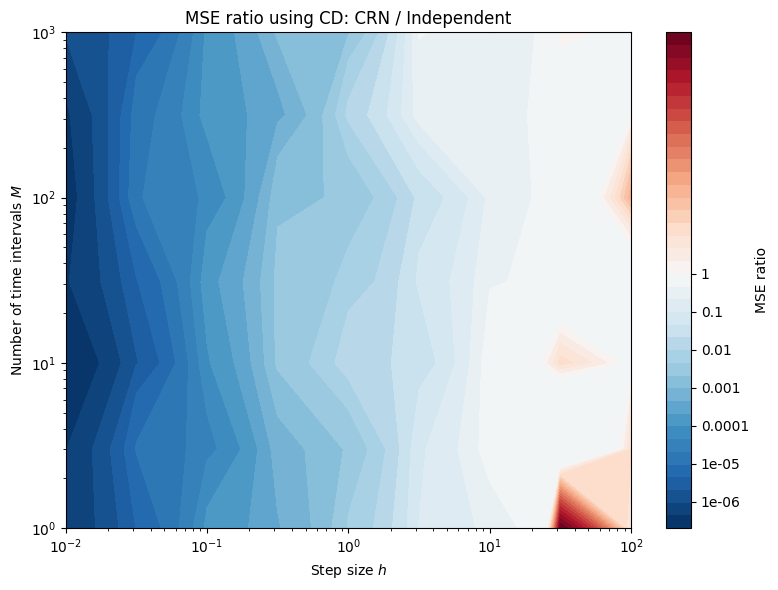

In [98]:
from matplotlib.colors import TwoSlopeNorm

H, M = np.meshgrid(h_values, steps_values)

# Work in log10-ratio space so that ratio = 1 maps to zero
log_ratio_mse = np.log10(ratio_mse)

log_vmin = log_ratio_mse.min()
log_vmax = log_ratio_mse.max()

plt.figure(figsize=(8, 6))

# Explicitly centre the colours at log10(1) = 0
map_norm = TwoSlopeNorm(vmin=log_vmin,vcenter=0.0,vmax=log_vmax)

# Ensure zero is included as an exact contour boundary
levels_below = np.linspace(log_vmin, 0.0, 20, endpoint=False)
levels_above = np.linspace(0.0, log_vmax, 20)
levels = np.concatenate([levels_below, levels_above])

contour = plt.contourf(H,M,log_ratio_mse,levels=levels,cmap="RdBu_r",norm=map_norm)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size $h$")
plt.ylabel("Number of time intervals $M$")
plt.title("MSE ratio using CD: CRN / Independent")

cbar = plt.colorbar(contour)

# Display the colourbar in the original ratio units
ratio_ticks = np.array([
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2
])

ratio_ticks = ratio_ticks[
    (ratio_ticks >= ratio_mse.min()) &
    (ratio_ticks <= ratio_mse.max())
]

cbar.set_ticks(np.log10(ratio_ticks))
cbar.set_ticklabels([f"{x:g}" for x in ratio_ticks])
cbar.set_label("MSE ratio")

plt.tight_layout()
plt.show()

Clearly, CRN are effective in reducing the MSE for low step sizes, but their effect is almost negligible and noisy for $h > 10$. This result is partly dependent on the fixed value of $N$ we chose, but the general behaviour is the same across its different values. For $h > 10$, the ratio is generally equal to 1, with the exception of some possible noise. The number of monitoring dates has no effect on the ratio. 

The above occurs because as $h$ increases, the paths and payoffs generated from the bumped initial prices $S_0+h$ and $S_0-h$ become increasingly different, even when they are generated using the same random shocks. As a result, the covariance between the two payoff estimates becomes less effective at reducing the variance of the finite-difference numerator. At the same time, the finite-difference bias becomes more important and is unaffected by CRN. Consequently,

$$
\frac{\operatorname{MSE}_{\mathrm{CRN}}}
{\operatorname{MSE}_{\mathrm{Independent}}}
\longrightarrow 1
$$

as $h$ becomes large.

Overall, the finite-difference estimators for arithmetic Asian calls exhibit the same fundamental bias–variance trade-off and optimal step-size scaling as for European calls. Path dependence changes the numerical constants and introduces monitoring frequency as an additional determinant of estimator variance, but does not alter the underlying finite-difference theory. Common random numbers substantially reduce MSE for practically relevant small step sizes, while their relative advantage diminishes as $h$ grows.

## Pathwise Differentiation

We analyse the properties of the method of Pathwise Differentiation for Asian calls. Since the MSE and variance of Pathwise estimations are equal (as there is no bias), we do not use the $100,000$-rep pathwise estimation as a benchmark to compute approximated MSEs in the following experiments, and only focus on the variance of the estimations.

We begin by confirming that a similar MSE behaviour to European calls holds across the moneyness-vol grid, for a fixed number of monitoring dates. We then investigate the effect of varying the number of monitoring dates under a fixed number of reps. Note that moneyness is only computed once, using the price at the start of the contract and not at any other monitoring dates.

In [72]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [73]:
trials = 100

# Fix steps and reps this time
reps = 1_000
steps = 4 # quarterly monitoring

# Rows correspond to moneyness, columns correspond to vol
pw_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        trial_deltas = np.empty(trials)
        # PW is unbiased, so MSE = variance
        for trial in range(trials):
            delta_pw = pathwise.mc_asian_call_delta_pw_estimate(s_i,K,T,r,vol_j,steps,reps)
            trial_deltas[trial] = delta_pw
        pw_mse[i, j] = np.var(trial_deltas, ddof=1)

# Convert the results into a labelled table
pw_error_table = pd.DataFrame(pw_mse, index=moneyness_values, columns=vol_values)

pw_error_table.index.name = "moneyness"
pw_error_table.columns.name = "vol"

display(pw_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000000e+00,0.000000e+00,1.261562e-07,2.777099e-07,0.000002,0.000004,0.000010,0.000017,0.000025,0.000055,...,0.000134,0.000164,0.000198,0.000195,0.000168,0.000258,0.000206,0.000275,0.000291,0.000364
0.725,0.000000e+00,0.000000e+00,1.997194e-07,9.366172e-07,0.000004,0.000009,0.000015,0.000031,0.000043,0.000070,...,0.000178,0.000165,0.000195,0.000200,0.000236,0.000241,0.000278,0.000289,0.000358,0.000314
0.750,0.000000e+00,7.917798e-08,8.557037e-07,3.945373e-06,0.000008,0.000021,0.000035,0.000046,0.000061,0.000089,...,0.000225,0.000212,0.000230,0.000298,0.000285,0.000268,0.000294,0.000402,0.000243,0.000326
0.775,5.989005e-08,5.320640e-07,2.835317e-06,1.155117e-05,0.000015,0.000032,0.000052,0.000063,0.000082,0.000123,...,0.000244,0.000205,0.000282,0.000273,0.000306,0.000281,0.000315,0.000381,0.000376,0.000358
0.800,2.764404e-07,2.637901e-06,9.529075e-06,2.257307e-05,0.000045,0.000061,0.000073,0.000128,0.000138,0.000133,...,0.000213,0.000247,0.000297,0.000418,0.000344,0.000346,0.000338,0.000396,0.000367,0.000392
0.825,1.998974e-06,9.433865e-06,2.270244e-05,4.097789e-05,0.000066,0.000078,0.000099,0.000145,0.000156,0.000160,...,0.000299,0.000237,0.000328,0.000307,0.000311,0.000297,0.000361,0.000335,0.000375,0.000420
0.850,8.036959e-06,2.201356e-05,4.223904e-05,8.383388e-05,0.000095,0.000135,0.000168,0.000170,0.000175,0.000233,...,0.000227,0.000311,0.000319,0.000341,0.000400,0.000365,0.000344,0.000444,0.000338,0.000382
0.875,3.270624e-05,6.870972e-05,8.364157e-05,1.205715e-04,0.000152,0.000225,0.000184,0.000232,0.000252,0.000263,...,0.000274,0.000362,0.000506,0.000294,0.000348,0.000360,0.000441,0.000340,0.000397,0.000420
0.900,7.115311e-05,1.120147e-04,1.851000e-04,1.625315e-04,0.000167,0.000238,0.000217,0.000310,0.000267,0.000231,...,0.000297,0.000372,0.000331,0.000434,0.000344,0.000397,0.000424,0.000416,0.000441,0.000420


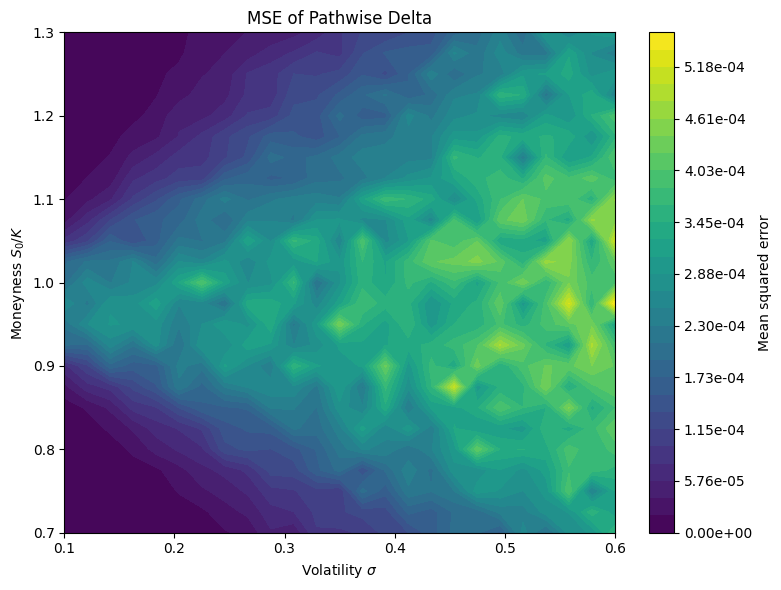

In [74]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(pw_mse.min(), pw_mse.max(), 30)

contour = plt.contourf(
    VOL,
    MONEYNESS,
    pw_mse,
    levels=levels
)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Pathwise Delta")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

We observe that the error is highest in the area close to a moneyness of 1, which widens as volatility increases. This is sensible: in general, simulated ATM options will exhibit greater variance in their Delta due to the closeness to the indicator function discontinuity. As the volatility of the underlying increases, this effect is more evident. On the other hand, deep OTM or ITM options will show a very low error for low volatility values for opposite equivalent reasons. For deep OTM or ITM options under large volatility, MSE increases since the ratio $A/K$ is much more variable, regardless of whether the indicator function yields 1 or 0.

Next, we study how increasing the number of time intervals $M$, and hence the number of averaged values $M+1$, changes the MSE of the Asian-call Delta estimation under the Pathwise estimator. In particular, we conduct a one-dimensional analysis for one ITM, one ATM, and one OTM option.

In [75]:
moneyness_values = np.asarray([0.9,1.0,1.1])
steps_values = np.logspace(0, 3, 7, dtype=int)

In [76]:
# Fix trials and reps
trials = 1000
reps = 1_000

# Rows correspond to moneyness, columns correspond to steps
pw_mse = np.empty((len(moneyness_values), len(steps_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, steps_j in enumerate(steps_values):
        trial_deltas = np.empty(trials)
        for trial in range(trials):
            delta_pw = pathwise.mc_asian_call_delta_pw_estimate(s_i,K,T,r,vol,steps_j,reps)
            trial_deltas[trial] = delta_pw
        # PW is unbiased, so MSE = variance
        pw_mse[i, j] = np.var(trial_deltas, ddof=1)

# Convert the results into a labelled table
pw_error_table_steps_only = pd.DataFrame(pw_mse,index=moneyness_values,columns=steps_values)

pw_error_table_steps_only.index.name = "moneyness"
pw_error_table_steps_only.columns.name = "steps"

display(pw_error_table_steps_only)

steps,1,3,10,31,100,316,1000
moneyness,,,,,,,
0.9,0.000241,0.000265,0.000247,0.000252,0.000262,0.000258,0.000255
1.0,0.000266,0.000299,0.000325,0.000302,0.000310,0.000260,0.000309
1.1,0.000162,0.000196,0.000177,0.000194,0.000199,0.000179,0.000205


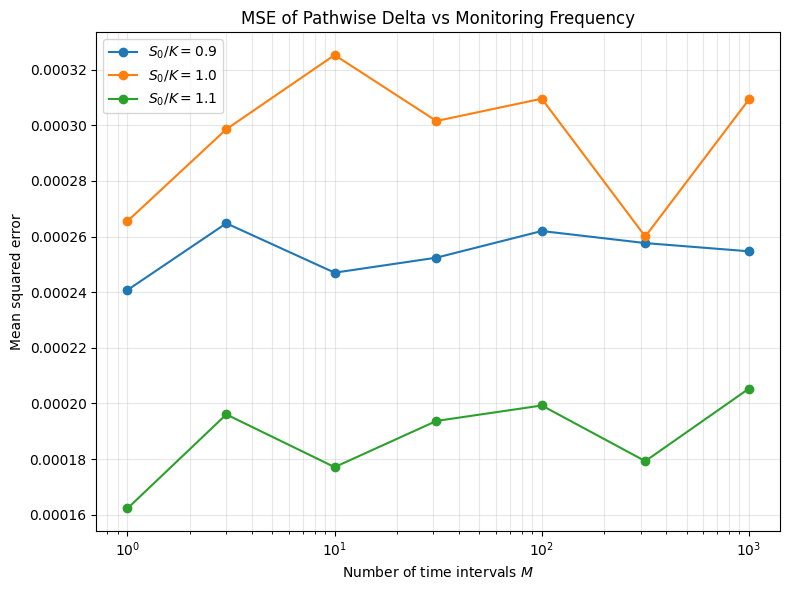

In [77]:
plt.figure(figsize=(8, 6))

for i, moneyness_i in enumerate(moneyness_values):
    plt.plot(
        steps_values,
        pw_mse[i, :],
        marker="o",
        label=fr"$S_0/K = {moneyness_i:.1f}$"
    )

plt.xscale("log")

plt.xlabel("Number of time intervals $M$")
plt.ylabel("Mean squared error")
plt.title("MSE of Pathwise Delta vs Monitoring Frequency")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

We observe that the MSE is highest for $S_0/K = 1$. This is sensible, as for this moneyness the average $A$ oscillates very close to the discontinuity of the indicator function, increasing the variance of the Delta estimation. On the other hand, MSE is lower for $S_0/K = 1.1$ than for $S_0/K = 0.9$. This is likely due to the skew of the GBM itself, which 'favours' larger positive prices of the underlying asset.

## Likelihood-Ratio

We analyse the appropriateness of the Likelihood-Ratio estimator for the Delta of an Asian call. We begin by investigating the MSE of the method in a moneyness-volatility grid, as done for European calls. Since the LR method is again theoretically unbiased, the MSE is equal to the variance of the estimations.

In [78]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [79]:
trials = 100

# Fix steps and reps this time
reps = 1_000
steps = 4 # quarterly monitoring

# Rows correspond to moneyness, columns correspond to vol
lr_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        trial_deltas = np.empty(trials)
        # LR is unbiased, so MSE = variance
        for trial in range(trials):
            delta_lr = likelihood_ratio.mc_asian_call_delta_lr_estimate(s_i,K,T,r,vol_j,steps,reps)
            trial_deltas[trial] = delta_lr
        lr_mse[i, j] = np.var(trial_deltas, ddof=1)

# Convert the results into a labelled table
lr_error_table = pd.DataFrame(lr_mse, index=moneyness_values, columns=vol_values)

lr_error_table.index.name = "moneyness"
lr_error_table.columns.name = "vol"

display(lr_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000000e+00,0.000000e+00,2.204899e-08,0.000002,0.000004,0.000007,0.000016,0.000039,0.000063,0.000078,...,0.000380,0.000403,0.000521,0.000493,0.000629,0.000719,0.000808,0.000853,0.000943,0.001073
0.725,0.000000e+00,0.000000e+00,1.399827e-07,0.000002,0.000016,0.000016,0.000044,0.000046,0.000098,0.000112,...,0.000433,0.000631,0.000528,0.000842,0.000727,0.000587,0.000802,0.000914,0.000850,0.001291
0.750,0.000000e+00,6.939373e-08,1.318695e-06,0.000006,0.000015,0.000045,0.000059,0.000118,0.000132,0.000180,...,0.000562,0.000683,0.000621,0.000915,0.000900,0.001005,0.000829,0.001039,0.001085,0.001251
0.775,2.626330e-09,6.303068e-07,7.540916e-06,0.000014,0.000036,0.000097,0.000107,0.000187,0.000192,0.000246,...,0.000596,0.000750,0.001117,0.001059,0.000917,0.000810,0.001204,0.000813,0.001113,0.001226
0.800,4.319796e-07,4.307376e-06,1.730370e-05,0.000035,0.000080,0.000121,0.000170,0.000258,0.000324,0.000381,...,0.000786,0.000791,0.000856,0.001092,0.000886,0.001399,0.001137,0.001356,0.001362,0.001499
0.825,5.179426e-06,1.540239e-05,4.537229e-05,0.000097,0.000193,0.000210,0.000252,0.000369,0.000376,0.000421,...,0.001030,0.000674,0.000874,0.001064,0.001065,0.001351,0.001595,0.001554,0.001302,0.001349
0.850,2.253816e-05,5.776997e-05,1.213410e-04,0.000138,0.000296,0.000321,0.000342,0.000436,0.000534,0.000629,...,0.001232,0.001378,0.001124,0.001448,0.001260,0.001603,0.001415,0.001444,0.002076,0.001176
0.875,5.001097e-05,1.180610e-04,2.266944e-04,0.000295,0.000422,0.000440,0.000537,0.000707,0.000762,0.000780,...,0.001071,0.000860,0.001148,0.001563,0.001589,0.001391,0.001581,0.001217,0.001399,0.001412
0.900,1.650120e-04,3.528255e-04,3.405624e-04,0.000447,0.000460,0.000869,0.000632,0.000687,0.000838,0.001052,...,0.001415,0.001147,0.001328,0.001384,0.001809,0.001527,0.001529,0.001826,0.002211,0.001746


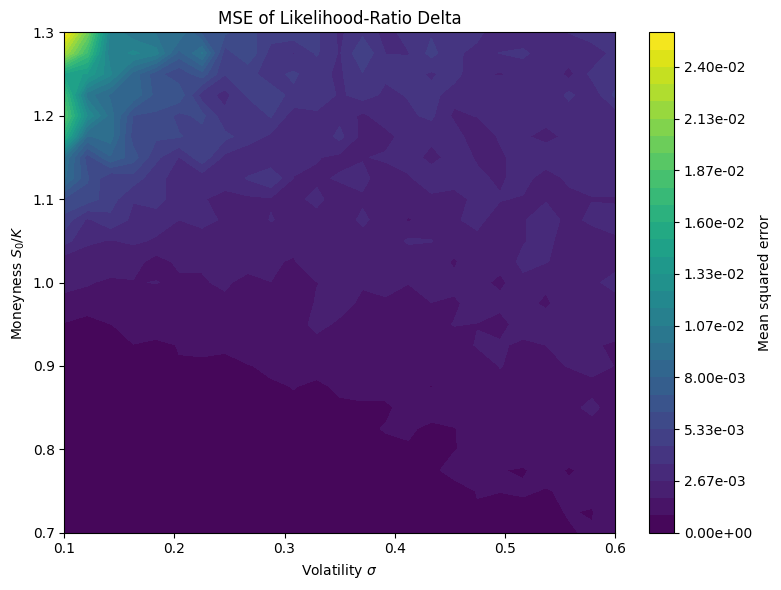

In [80]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(lr_mse.min(), lr_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,lr_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Likelihood-Ratio Delta")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

We observe that a pattern similar to that of European calls emerges. This is for the same reasons exposed before. Interestingly, for OTM options, high volatility increases the error of the estimations, while for ITM options, high volatility decreases it.

For ITM options, the payoff is positive on almost every path and contains a substantial approximately constant component. When multiplied by the zero-mean likelihood-ratio score, this component adds noise without contributing to the expected Delta. Since the score is proportional to $1/\sigma$, this noise becomes particularly large when volatility is low, producing the high MSE observed in the upper-left region.

For OTM options under low volatility, the payoff is zero on almost every path. Consequently, both the LR observations and the true Delta are close to zero, resulting in the low MSE observed in the lower-left region. As volatility increases, OTM options finish in the money more frequently, creating more nonzero and variable LR observations and increasing the MSE. On the other hand, for ITM options, increasing volatility reduces the magnitude of the $1/\sigma$ score and weakens the large low-volatility noise component, causing the MSE to decrease.

We now investigate the effect of increasing the number of monitoring dates $M$ on the MSE, at three different moneyness values and under constant remaining parameters.

In [81]:
moneyness_values = np.asarray([0.9,1.0,1.1])
steps_values = np.logspace(0, 3, 7, dtype=int)

In [82]:
# Fix trials and reps
trials = 1000
reps = 1_000

# Rows correspond to moneyness, columns correspond to steps
lr_mse_2 = np.empty((len(moneyness_values), len(steps_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, steps_j in enumerate(steps_values):
        trial_deltas = np.empty(trials)
        for trial in range(trials):
            delta_lr = likelihood_ratio.mc_asian_call_delta_lr_estimate(s_i,K,T,r,vol,steps_j,reps)
            trial_deltas[trial] = delta_lr
        # LR is unbiased, so MSE = variance
        lr_mse_2[i, j] = np.var(trial_deltas, ddof=1)

# Convert the results into a labelled table
lr_error_table_steps_only = pd.DataFrame(lr_mse_2,index=moneyness_values,columns=steps_values)

lr_error_table_steps_only.index.name = "moneyness"
lr_error_table_steps_only.columns.name = "steps"

display(lr_error_table_steps_only)

steps,1,3,10,31,100,316,1000
moneyness,,,,,,,
0.9,0.000450,0.000767,0.001310,0.002788,0.008978,0.025450,0.081829
1.0,0.000797,0.001531,0.003176,0.008137,0.024518,0.072376,0.224420
1.1,0.000976,0.002236,0.005973,0.016592,0.051945,0.173307,0.475499


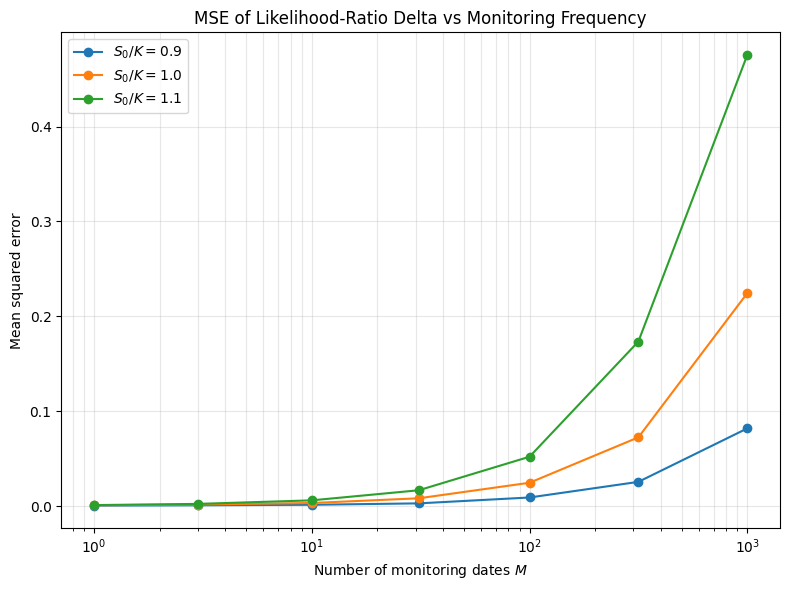

In [83]:
plt.figure(figsize=(8, 6))

for i, moneyness_i in enumerate(moneyness_values):
    plt.plot(
        steps_values,
        lr_mse_2[i, :],
        marker="o",
        label=fr"$S_0/K = {moneyness_i:.1f}$"
    )

plt.xscale("log")

plt.xlabel("Number of monitoring dates $M$")
plt.ylabel("Mean squared error")
plt.title("MSE of Likelihood-Ratio Delta vs Monitoring Frequency")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

It is clear that, as $M$ increases, the MSE increases. For the Asian call, we write the individual LR observation as

$$
D_M=H_MW_M+G_M,
$$

where

$$
H_M=e^{-rT}(A_M-K)^+,
\qquad
W_M=\frac{Z_1}{S_0\sigma\sqrt{T/M}},
\qquad
G_M=\frac{e^{-rT}}{M+1}\mathbf{1}_{\{A_M>K\}}.
$$

The variance of the resulting estimator is therefore

$$
\operatorname{Var}(\widehat{\Delta}_{LR})
=
\frac{1}{N}
\left[
\mathbb{E}\left((H_MW_M+G_M)^2\right)
-
\Delta_M^2
\right].
$$

When the later path values are fixed, only the first transition density contributes to the LR score $W_M$. The separate term $G_M$ accounts for the direct dependence of the arithmetic average on the initial value $S_0$. As $M$ increases, the first interval $T/M$ becomes shorter and the factor $1/\sqrt{T/M}$ grows, making the LR score increasingly variable. However, $H_M$, $G_M$, and their joint distribution with $W_M$ also depend on $M$, so the variance is not required to grow exactly linearly.

In this experiment, the MSE also increases monotonically with moneyness. This follows primarily from the term $H_MW_M$: for more ITM options, the payoff $H_M$ is positive more frequently and is generally larger, so the increasingly variable LR weight is multiplied by larger values. For OTM options, many observations instead have $H_M=0$, limiting the effect of the noisy LR weight.

To investigate whether MSE follows an approximate power-law relationship with $M$, we generate a log-log plot of the above results for $S_0/K=1$.

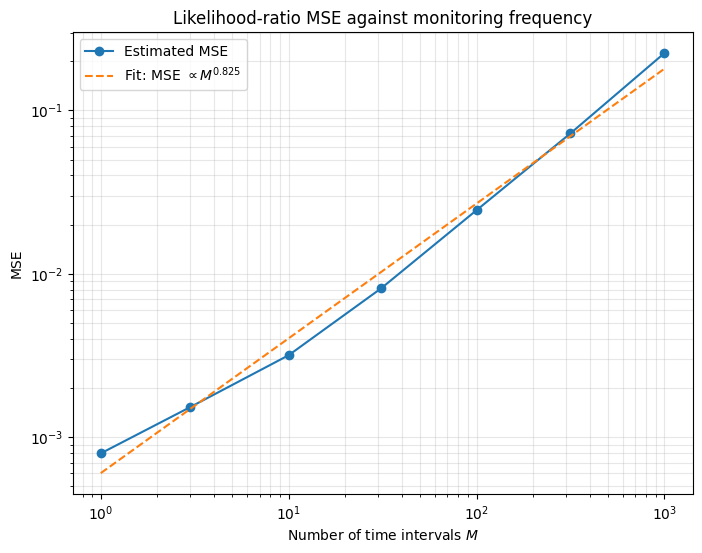

Log-log gradient: 0.8250


In [99]:
mse_atm = lr_mse_2[1, :]

# Fit a straight line in log-log space
log_M = np.log(steps_values)
log_mse = np.log(mse_atm)

gradient, intercept = np.polyfit(log_M, log_mse, 1)

# Obtain fitted MSE values
fitted_mse = np.exp(intercept) * np.array(steps_values)**gradient

# Plot results
plt.figure(figsize=(8,6))

plt.loglog(steps_values, mse_atm, marker="o", label="Estimated MSE")
plt.loglog(
    steps_values,
    fitted_mse,
    linestyle="--",
    label=fr"Fit: MSE $\propto M^{{{gradient:.3f}}}$"
)

plt.xlabel("Number of time intervals $M$")
plt.ylabel("MSE")
plt.title("Likelihood-ratio MSE against monitoring frequency")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

print(f"Log-log gradient: {gradient:.4f}")

The log-log fit suggests an approximate relationship of the form $\mathrm{MSE}\propto M^{0.83}$ for this run. This exponent is empirical and may vary slightly between runs. Its proximity to $1/2$ is consistent with the explicit $\sqrt{M}$ dependence of the LR score, although the payoff and the remaining components of the estimator also depend on $M$. Consequently, the LR method becomes a less attractive choice as $M$ grows, despite remaining unbiased.

Finally, we implement payoff centring for the Asian-call LR estimator. Let $D=HW+G$ denote the ordinary LR observation. Since $\mathbb{E}[W]=0$, the centred observation

$$
D_c=(H-c)W+G=D-cW
$$

has the same expectation. The variance-minimising constant is

$$
c^*
=
\frac{\mathbb{E}[DW]}{\mathbb{E}[W^2]}
=
\frac{\mathbb{E}[(HW+G)W]}{\mathbb{E}[W^2]},
$$

which is estimated using a separate pilot sample.

In [85]:
# Define function to estimate optimal centring constant c
def optimal_c_asian(s,K,T,r,vol,steps,reps):
    Z = np.random.standard_normal((reps,steps))
    paths = path_simulator.multiple_step_paths(s,T,r,vol,steps,reps,Z)
    discount = np.exp(-r*T)
    path_averages = np.mean(paths,axis=1)
    H = discount*payoffs.asian_call_payoff(paths,K)
    dt = T/steps
    W = Z[:,0] / (s*vol*np.sqrt(dt))
    G = discount*(path_averages > K)/paths.shape[1]
    D = H*W + G
    c = np.sum(D*W) / np.sum(W**2)
    return c

In [86]:
# Values to investigate
moneyness_values = np.linspace(0.7, 1.3, 25)
vol_values = np.linspace(0.10, 0.60, 25)

In [87]:
trials = 100

# Fix steps and reps this time
reps = 1_000
steps = 4 # quarterly monitoring

# Rows correspond to moneyness, columns correspond to vol
lr_centred_mse = np.empty((len(moneyness_values), len(vol_values)))

# Populate the table
for i, moneyness_i in enumerate(moneyness_values):
    s_i = K * moneyness_i
    for j, vol_j in enumerate(vol_values):
        trial_deltas = np.empty(trials)
        c = optimal_c_asian(s_i,K,T,r,vol_j,steps,reps)
        # LR is unbiased, so MSE = variance
        for trial in range(trials):
            delta_lr_centred = likelihood_ratio.mc_asian_call_delta_lr_centred_estimate(s_i,K,T,r,vol_j,steps,reps,c)
            trial_deltas[trial] = delta_lr_centred
        lr_centred_mse[i, j] = np.var(trial_deltas, ddof=1)

# Convert the results into a labelled table
lr_centred_error_table = pd.DataFrame(lr_centred_mse, index=moneyness_values, columns=vol_values)

lr_centred_error_table.index.name = "moneyness"
lr_centred_error_table.columns.name = "vol"

display(lr_centred_error_table)

vol,0.100000,0.120833,0.141667,0.162500,0.183333,0.204167,0.225000,0.245833,0.266667,0.287500,...,0.412500,0.433333,0.454167,0.475000,0.495833,0.516667,0.537500,0.558333,0.579167,0.600000
moneyness,,,,,,,,,,,,,,,,,,,,,
0.700,0.000000e+00,0.000000e+00,0.000000e+00,3.372764e-07,0.000002,0.000008,0.000014,0.000037,0.000051,0.000077,...,0.000399,0.000419,0.000426,0.000389,0.000536,0.000555,0.000698,0.000749,0.000801,0.000846
0.725,0.000000e+00,0.000000e+00,1.038970e-07,1.102227e-06,0.000006,0.000019,0.000036,0.000064,0.000080,0.000164,...,0.000374,0.000358,0.000586,0.000510,0.000619,0.000543,0.000569,0.000673,0.000796,0.001074
0.750,0.000000e+00,2.636829e-08,1.018421e-06,7.362738e-06,0.000023,0.000033,0.000063,0.000114,0.000115,0.000189,...,0.000372,0.000489,0.000412,0.000646,0.000675,0.000789,0.000708,0.000944,0.001156,0.000739
0.775,1.016036e-07,1.081123e-06,6.582011e-06,2.797354e-05,0.000053,0.000080,0.000116,0.000146,0.000180,0.000239,...,0.000449,0.000525,0.000616,0.000581,0.000921,0.000598,0.000921,0.000836,0.001070,0.001134
0.800,1.772155e-07,6.302096e-06,1.373546e-05,4.436515e-05,0.000059,0.000137,0.000170,0.000193,0.000321,0.000368,...,0.000496,0.000654,0.000836,0.000916,0.000773,0.000744,0.000881,0.001104,0.000994,0.001179
0.825,4.588395e-06,2.521380e-05,5.734319e-05,7.512513e-05,0.000123,0.000246,0.000251,0.000318,0.000336,0.000341,...,0.000601,0.000742,0.000794,0.000728,0.000716,0.001153,0.001170,0.001149,0.001184,0.001334
0.850,1.489018e-05,4.556469e-05,1.009091e-04,1.647560e-04,0.000291,0.000325,0.000380,0.000403,0.000508,0.000676,...,0.000763,0.000871,0.000971,0.001005,0.001035,0.001139,0.000910,0.000906,0.001271,0.000759
0.875,5.550745e-05,1.020950e-04,1.810048e-04,2.786155e-04,0.000375,0.000365,0.000440,0.000494,0.000522,0.000484,...,0.000977,0.001080,0.000675,0.001115,0.001218,0.001114,0.001102,0.001172,0.001052,0.000855
0.900,1.367070e-04,2.160427e-04,3.063783e-04,3.278041e-04,0.000409,0.000475,0.000633,0.000495,0.000526,0.000634,...,0.000696,0.000826,0.001112,0.000896,0.001279,0.001582,0.001115,0.001335,0.001068,0.001541


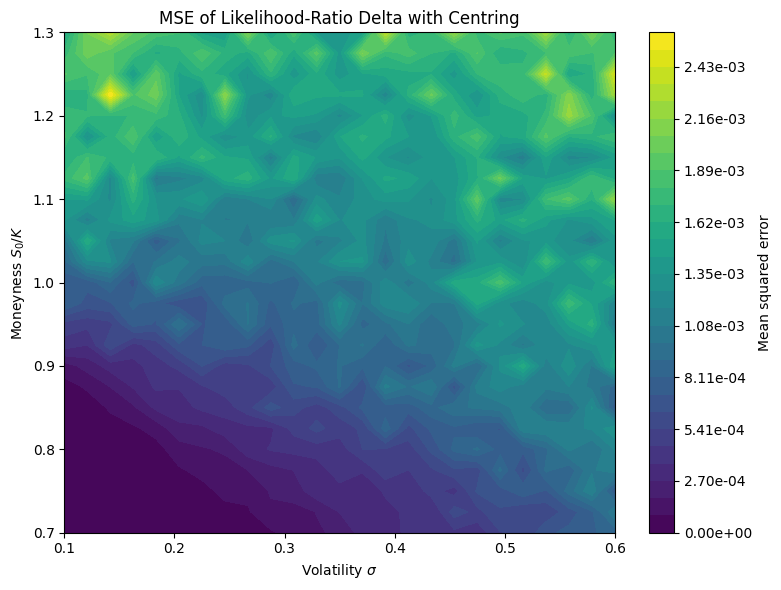

In [88]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

plt.figure(figsize=(8, 6))

# Linear contour levels and linear axes
levels = np.linspace(lr_centred_mse.min(), lr_centred_mse.max(), 30)

contour = plt.contourf(VOL,MONEYNESS,lr_centred_mse,levels=levels)

plt.xlabel(r"Volatility $\sigma$")
plt.ylabel(r"Moneyness $S_0/K$")
plt.title("MSE of Likelihood-Ratio Delta with Centring")

cbar = plt.colorbar(contour, format="%.2e")
cbar.set_label("Mean squared error")

plt.tight_layout()
plt.show()

For a better comparison, we compute the ratio $\frac{\mathrm{MSE}_{\mathrm{centred\ LR}}}{\mathrm{MSE}_{\mathrm{ordinary\ LR}}}$. Values below 1 indicate that Payoff Centring reduces the MSE.

In [89]:
# Compute the ratio safely
lr_mse_ratio = np.divide(
    lr_centred_mse,
    lr_mse,
    out=np.full_like(lr_centred_mse, np.nan, dtype=float),
    where=lr_mse > 0
)

In [90]:
# Mask undefined and non-positive values
ratio_plot = np.ma.masked_invalid(lr_mse_ratio)
ratio_plot = np.ma.masked_less_equal(ratio_plot, 0)

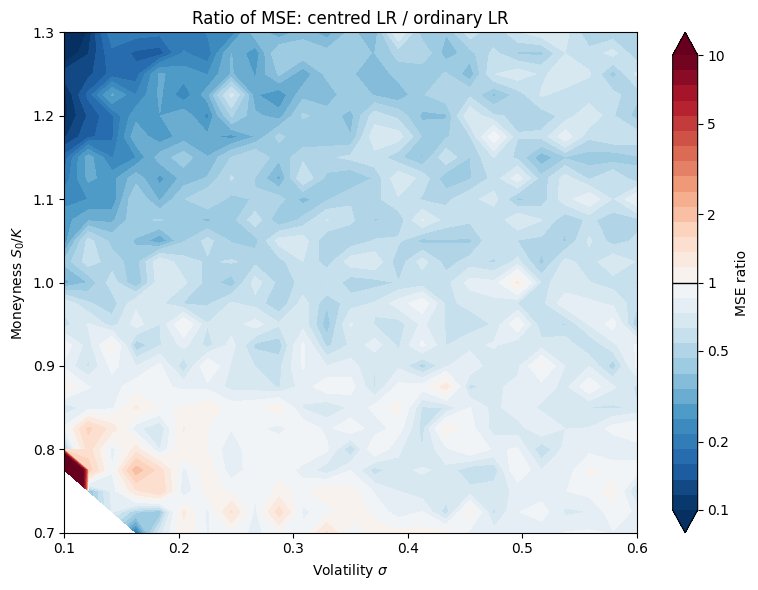

In [91]:
# Grid for the plot
VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

fig, ax = plt.subplots(figsize=(8, 6))

# Reciprocal limits ensure that ratio = 1 is at the colour midpoint
vmin, vmax = 0.1, 10.0
levels = np.geomspace(vmin, vmax, 31)

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")

contour = ax.contourf(VOL,MONEYNESS,ratio_plot,levels=levels,cmap=cmap,norm=LogNorm(vmin=vmin, vmax=vmax),extend="both")

ax.set_xlabel(r"Volatility $\sigma$")
ax.set_ylabel(r"Moneyness $S_0/K$")
ax.set_title("Ratio of MSE: centred LR / ordinary LR")

ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10]
cbar = fig.colorbar(contour, ax=ax, ticks=ticks)
cbar.ax.set_yticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
cbar.set_label("MSE ratio")
cbar.ax.axhline(1.0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

In general, LR with centring is highly effective for estimating the Delta of Asian calls relative to LR without centring. In particular, it appears to be especially effective for low-volatility ITM options, following a similar pattern to European calls.

We finish this Notebook by comparing the best versions of the three investigated methods across different option parameter values. In particular, we consider the Central Difference method with CRN and an approximately optimal step size $h$, Pathwise Differentiation, and the Likelihood-Ratio method with Payoff Centring. We again use MSE and Runtime $\times$ MSE as the two comparative metrics, beginning with the usual moneyness-volatility grid.

The comparisons are conducted for different numbers of time intervals $M$, representing quarterly, daily, and hourly monitoring. Since the arithmetic average includes $S_0$, each simulation contains $M+1$ averaged values. For simplicity, the approximately optimal value of relative_h for the Central Difference method was selected using the midpoint of the moneyness-volatility grid, $M=4$, and $N=1000$.

In [92]:
def run_asian_comparison(steps):

    trials = 100
    reps = 1_000
    pilot_reps = 1_000

    relative_h = 0.05

    shape = (len(moneyness_values), len(vol_values))

    # MSE arrays
    cd_crn_mse = np.empty(shape)
    pw_mse = np.empty(shape)
    lr_centred_mse = np.empty(shape)

    # Estimator runtime arrays
    cd_crn_runtime = np.empty(shape)
    pw_runtime = np.empty(shape)
    lr_centred_runtime = np.empty(shape)

    # Separate runtime required to estimate c
    lr_c_runtime = np.empty(shape)

    for i, moneyness_i in enumerate(moneyness_values):
        s_i = K * moneyness_i
        h_i = relative_h * s_i

        for j, vol_j in enumerate(vol_values):
            real_delta = pathwise.mc_asian_call_delta_pw_estimate(
                s_i,K,T,r,vol_j,steps,100_000
            )

            start = time.perf_counter()
            c_ij = optimal_c_asian(
                s_i,K,T,r,vol_j,steps,pilot_reps
            )
            lr_c_runtime[i, j] = time.perf_counter() - start

            cd_trial_errors = np.empty(trials)
            pw_trial_errors = np.empty(trials)
            lr_trial_errors = np.empty(trials)

            cd_trial_runtimes = np.empty(trials)
            pw_trial_runtimes = np.empty(trials)
            lr_trial_runtimes = np.empty(trials)

            for trial in range(trials):
                start = time.perf_counter()
                delta_cd_crn = finite_difference.mc_asian_call_delta_cd_estimate_crn(
                    s_i, K, T, r, vol_j, steps, reps, h_i
                )
                cd_trial_runtimes[trial] = time.perf_counter() - start

                start = time.perf_counter()
                delta_pw = pathwise.mc_asian_call_delta_pw_estimate(
                    s_i, K, T, r, vol_j, steps, reps
                )
                pw_trial_runtimes[trial] = time.perf_counter() - start

                start = time.perf_counter()
                delta_lr_centred = likelihood_ratio.mc_asian_call_delta_lr_centred_estimate(
                    s_i, K, T, r, vol_j, steps, reps, c_ij
                )
                lr_trial_runtimes[trial] = time.perf_counter() - start

                cd_trial_errors[trial] = (delta_cd_crn - real_delta)**2
                pw_trial_errors[trial] = (delta_pw - real_delta)**2
                lr_trial_errors[trial] = (delta_lr_centred - real_delta)**2

            cd_crn_mse[i, j] = np.mean(cd_trial_errors)
            pw_mse[i, j] = np.mean(pw_trial_errors)
            lr_centred_mse[i, j] = np.mean(lr_trial_errors)

            cd_crn_runtime[i, j] = np.mean(cd_trial_runtimes)
            pw_runtime[i, j] = np.mean(pw_trial_runtimes)
            lr_centred_runtime[i, j] = np.mean(lr_trial_runtimes)

    return (
        cd_crn_mse,
        pw_mse,
        lr_centred_mse,
        cd_crn_runtime,
        pw_runtime,
        lr_centred_runtime,
        lr_c_runtime
    )

In [100]:
quarterly_results = run_asian_comparison(steps=4)


### CODE COMMENTED OUT FOR SPEED PURPOSES. FOR FURTHER ANALYSIS, THE CODE MAY BE UNCOMMENTED

# daily_results = run_asian_comparison(steps=252)

# hourly_results = run_asian_comparison(steps=2016) # taking (252 * 8) as the total hours of monitoring

In [101]:
def make_comparison_tables(results):
    (
        cd_crn_mse,
        pw_mse,
        lr_centred_mse,
        cd_crn_runtime,
        pw_runtime,
        lr_centred_runtime,
        lr_c_runtime
    ) = results

    # MSE table
    mse_rows = []

    for i, moneyness_i in enumerate(moneyness_values):
        for j, vol_j in enumerate(vol_values):
            mse_rows.append({
                "moneyness": moneyness_i,
                "volatility": vol_j,
                "CD with CRN": cd_crn_mse[i, j],
                "Pathwise": pw_mse[i, j],
                "Centred LR": lr_centred_mse[i, j]
            })

    mse_table = pd.DataFrame(mse_rows).set_index(
        ["moneyness", "volatility"]
    )

    mse_table["Best method"] = mse_table[
        ["CD with CRN", "Pathwise", "Centred LR"]
    ].idxmin(axis=1)


    # MSE x Runtime table; Runtime required to estimate c is deliberately excluded
    runtime_mse_rows = []

    for i, moneyness_i in enumerate(moneyness_values):
        for j, vol_j in enumerate(vol_values):
            runtime_mse_rows.append({
                "moneyness": moneyness_i,
                "volatility": vol_j,
                "CD with CRN": cd_crn_mse[i, j] * cd_crn_runtime[i, j],
                "Pathwise": pw_mse[i, j] * pw_runtime[i, j],
                "Centred LR": lr_centred_mse[i, j] * lr_centred_runtime[i, j]
            })

    runtime_mse_table = pd.DataFrame(runtime_mse_rows).set_index(
        ["moneyness", "volatility"]
    )

    runtime_mse_table["Best method"] = runtime_mse_table[
        ["CD with CRN", "Pathwise", "Centred LR"]
    ].idxmin(axis=1)

    return mse_table, runtime_mse_table

In [102]:
quarterly_mse_table, quarterly_runtime_mse_table = make_comparison_tables(
    quarterly_results
)


### CODE COMMENTED OUT FOR SPEED PURPOSES. FOR FURTHER ANALYSIS, THE CODE MAY BE UNCOMMENTED

# daily_mse_table, daily_runtime_mse_table = make_comparison_tables(
#     daily_results
# )

# hourly_mse_table, hourly_runtime_mse_table = make_comparison_tables(
#     hourly_results
# )

In [108]:
def plot_comparison(results, monitoring_label, metric="mse"):
    (
        cd_crn_mse,
        pw_mse,
        lr_centred_mse,
        cd_crn_runtime,
        pw_runtime,
        lr_centred_runtime,
        _
    ) = results

    if metric == "mse":
        data = [
            cd_crn_mse,
            pw_mse,
            lr_centred_mse
        ]
        metric_label = "Mean squared error"
        title_metric = "MSE"

    elif metric == "runtime_mse":
        data = [
            cd_crn_mse * cd_crn_runtime,
            pw_mse * pw_runtime,
            lr_centred_mse * lr_centred_runtime
        ]
        metric_label = "MSE × Runtime"
        title_metric = "MSE × Runtime"

    else:
        raise ValueError("metric must be 'mse' or 'runtime_mse'")

    VOL, MONEYNESS = np.meshgrid(vol_values, moneyness_values)

    all_values = np.concatenate([x.ravel() for x in data])

    positive_values = all_values[
        (all_values > 0) & np.isfinite(all_values)
    ]

    vmin = max(positive_values.min(), 10**(-16))
    vmax = positive_values.max()

    levels = np.geomspace(vmin, vmax, 200)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    titles = [
        "Central Differences with CRN",
        "Pathwise Differentiation",
        "Centred Likelihood Ratio"
    ]

    for ax, values, title in zip(axes, data, titles):
        contour = ax.contourf(VOL,MONEYNESS,values,levels=levels,norm=LogNorm(vmin=vmin, vmax=vmax),cmap="viridis")
        ax.set_title(title)
        ax.set_xlabel(r"Volatility $\sigma$")

    axes[0].set_ylabel(r"Moneyness $S_0/K$")

    ticks = np.geomspace(vmin, vmax, 9)

    cbar = fig.colorbar(
        contour,
        ax=axes,
        orientation="horizontal",
        pad=0.12,
        fraction=0.08,
        aspect=40,
        ticks=ticks
    )

    cbar.set_label(metric_label)
    cbar.ax.xaxis.set_major_formatter(
        FormatStrFormatter("%.1e")
    )

    fig.suptitle(
        f"{title_metric} Comparison Across Methods ({monitoring_label} Monitoring)",
        fontsize=14
    )

    plt.show()

/var/folders/gn/xbr76yxx2l7gxg96sn637yn00000gn/T/ipykernel_10731/1127300525.py:61: UserWarning: Log scale: values of z <= 0 have been masked
  contour = ax.contourf(VOL,MONEYNESS,values,levels=levels,norm=LogNorm(vmin=vmin, vmax=vmax),cmap="viridis")


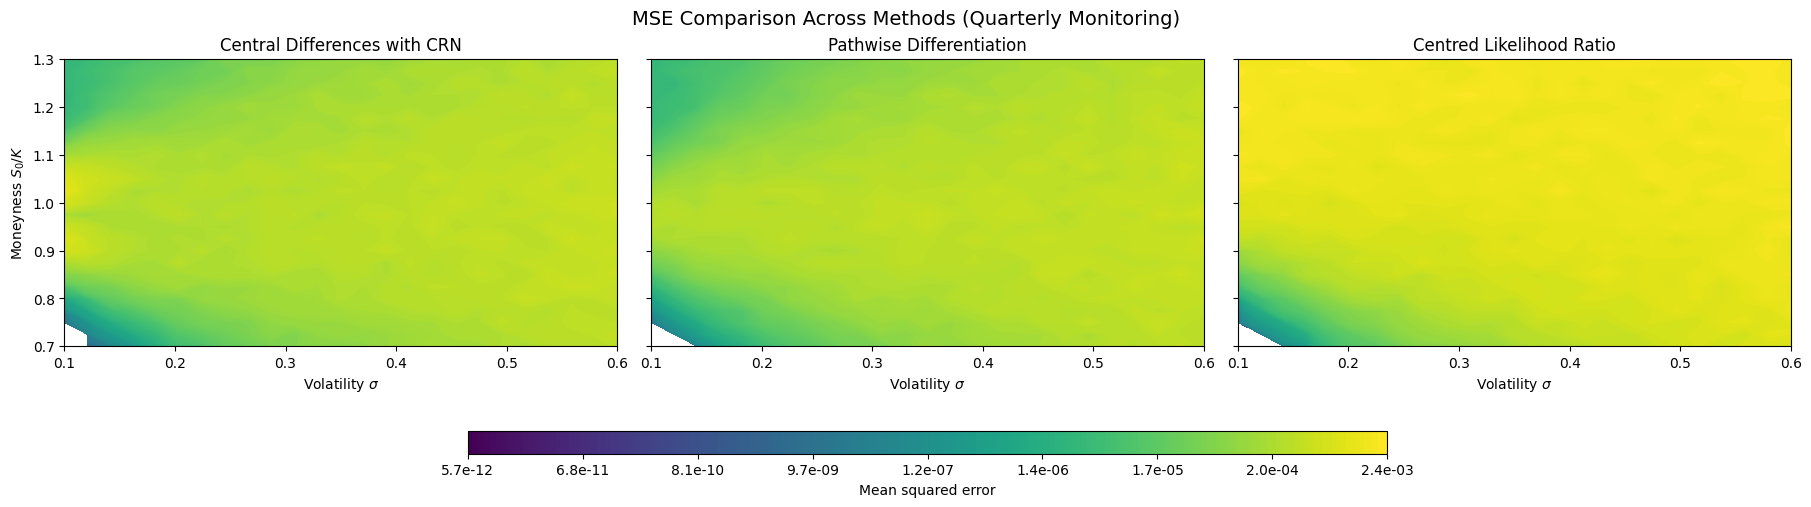

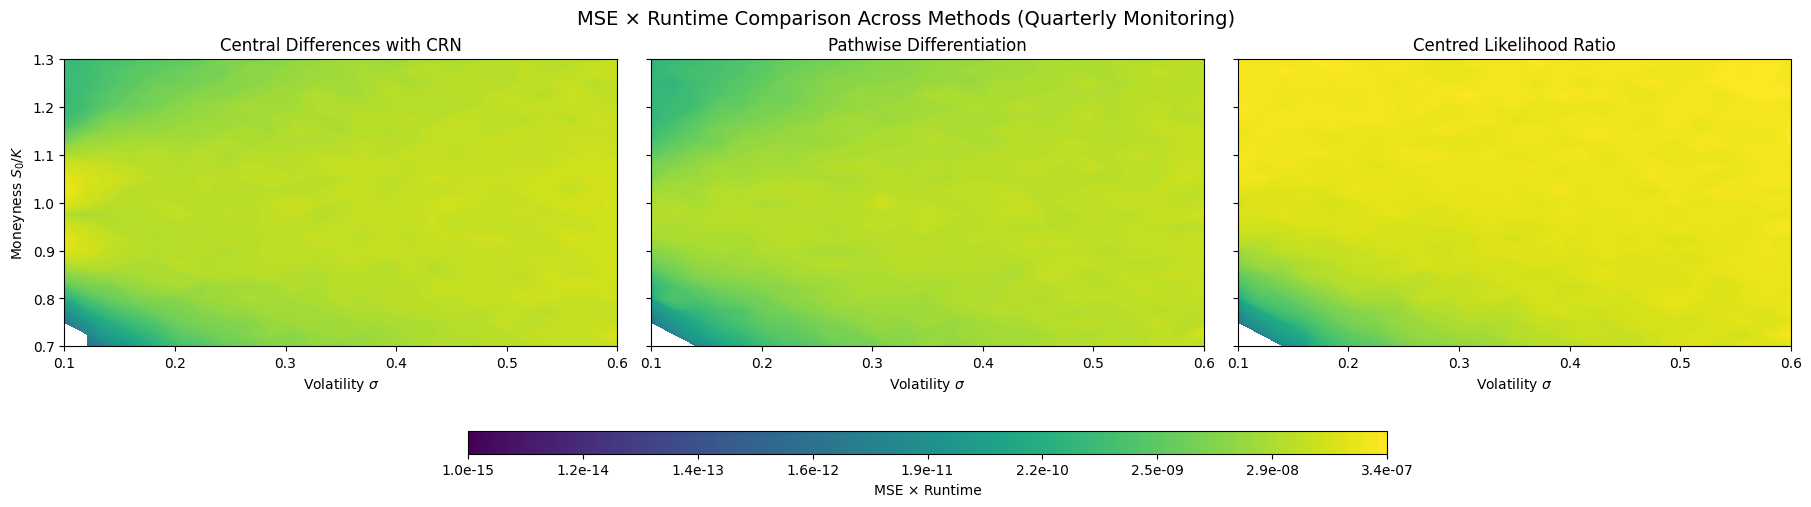

In [109]:
plot_comparison(quarterly_results, "Quarterly", metric="mse")
plot_comparison(quarterly_results, "Quarterly", metric="runtime_mse")


### CODE COMMENTED OUT FOR SPEED PURPOSES. FOR FURTHER ANALYSIS, THE CODE MAY BE UNCOMMENTED

# plot_comparison(daily_results, "Daily", metric="mse")
# plot_comparison(daily_results, "Daily", metric="runtime_mse")

# plot_comparison(hourly_results, "Hourly", metric="mse")
# plot_comparison(hourly_results, "Hourly", metric="runtime_mse")

Note that the white regions above correspond to empirical MSE values of zero. These occur in deeply OTM, low-volatility cases in which no simulated paths activate the payoff. Since zero cannot be represented under logarithmic normalisation, these values are masked in the plots. Additionally, only the case $M=4$ is included by default in this notebook; the daily and hourly comparison code is commented out to reduce its execution time.

For quarterly monitoring ($M=4$), it is visually clear that Pathwise Differentiation dominates under both the MSE and Runtime $\times$ MSE metrics. In fact, the plots are almost identical under both metrics, despite the values at each point in the grid being different.

Consequently, Pathwise Differentiation is again preferred for estimating the Delta of Asian call options, for reasons similar to those observed for the European call. In addition, its MSE remains comparatively stable as the number of time intervals varies. This makes its error easier to control and avoids the increase observed for the Likelihood-Ratio method as $M$ grows. Although Central Differences with CRN produce similar values, Pathwise Differentiation is also preferable because it does not require the computation of an approximately optimal tuning parameter such as $h$.

As a side remark, the plots also suggest that Central Differences with CRN approach Pathwise Differentiation as the number of simulations increases and the approximately optimal step size $h$ consequently decreases.